In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [112]:
# imports
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import random
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [113]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import random
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [114]:
# Reset TensorFlow / Keras state
# tf.keras.backend.clear_session()

In [115]:
# Read in train and test datasets

# Define paths
drive_dir = Path('/content/drive/MyDrive/Grad_School/SEIS_766 Vision AI/final_project/data/')
csv_path = drive_dir / "ISIC_2020_Training_GroundTruth.csv"

train_dir = drive_dir / 'train'
test_dir = drive_dir / 'test'

print(f'Train dir: {train_dir}')
print(f'Test dir: {test_dir}')

Train dir: /content/drive/MyDrive/Grad_School/SEIS_766 Vision AI/final_project/data/train
Test dir: /content/drive/MyDrive/Grad_School/SEIS_766 Vision AI/final_project/data/test


In [116]:
# Read Labels
labels_df = pd.read_csv(csv_path)

# Build filename column
labels_df["filename"] = labels_df["image_name"] + ".jpg"

# Keep only images that are actually in each folder
train_files = {p.name for p in train_dir.glob("*.jpg")}
test_files = {p.name for p in test_dir.glob("*.jpg")}

train_df = labels_df[labels_df["filename"].isin(train_files)].copy()
test_df = labels_df[labels_df["filename"].isin(test_files)].copy()

# Full paths
train_df["filepath"] = train_df["filename"].apply(lambda x: str(train_dir / x))
test_df["filepath"] = test_df["filename"].apply(lambda x: str(test_dir / x))

# Label column
train_df["label"] = train_df["target"].astype("int32")
test_df["label"] = test_df["target"].astype("int32")

assert len(train_df) > 0, "No training images matched the CSV labels."
assert len(test_df) > 0, "No test images matched the CSV labels."

missing_train = train_df.loc[~train_df["filepath"].map(lambda p: Path(p).exists()), "filepath"]
missing_test = test_df.loc[~test_df["filepath"].map(lambda p: Path(p).exists()), "filepath"]

assert missing_train.empty, f'Some training image paths do not exist. Example: {missing_train.iloc[0]}'
assert missing_test.empty, f'Some test image paths do not exist. Example: {missing_test.iloc[0]}'

print("Train class counts:")
print(train_df["label"].value_counts().sort_index())
print("\nTest class counts:")
print(test_df["label"].value_counts().sort_index())
print()
print(train_df[["filepath", "label"]].head())
print(test_df[["filepath", "label"]].head())

Train class counts:
label
0    400
1    467
Name: count, dtype: int64

Test class counts:
label
0    100
1    117
Name: count, dtype: int64

                                              filepath  label
83   /content/drive/MyDrive/Grad_School/SEIS_766 Vi...      0
91   /content/drive/MyDrive/Grad_School/SEIS_766 Vi...      1
223  /content/drive/MyDrive/Grad_School/SEIS_766 Vi...      0
235  /content/drive/MyDrive/Grad_School/SEIS_766 Vi...      1
348  /content/drive/MyDrive/Grad_School/SEIS_766 Vi...      0
                                               filepath  label
197   /content/drive/MyDrive/Grad_School/SEIS_766 Vi...      0
314   /content/drive/MyDrive/Grad_School/SEIS_766 Vi...      1
372   /content/drive/MyDrive/Grad_School/SEIS_766 Vi...      0
1335  /content/drive/MyDrive/Grad_School/SEIS_766 Vi...      1
1351  /content/drive/MyDrive/Grad_School/SEIS_766 Vi...      0


In [117]:
# Display one example from each class in the training set

# class_names = {0: "Benign", 1: "Malignant"}

# sample_0 = train_df[train_df["label"] == 0].iloc[0]
# sample_1 = train_df[train_df["label"] == 1].iloc[0]

# fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# for ax, sample in zip(axes, [sample_0, sample_1]):
#   img = tf.keras.utils.load_img(sample["filepath"], target_size=IMG_SIZE)
#   ax.imshow(img)
#   ax.set_title(f'Class {sample["label"]}: {class_names[sample["label"]]}')
#   ax.axis("off")

# plt.tight_layout()
# plt.show()

In [118]:
# Now, turn this into TensorFlow Datasets
IMG_SIZE = (224, 224)
BATCH_SIZE = 64

def load_image(path, label):
  img = tf.io.read_file(path)
  img = tf.image.decode_jpeg(img, channels=3)
  img = tf.image.resize(img, IMG_SIZE)
  img = tf.image.convert_image_dtype(img, tf.float32)
  label = tf.cast(label, tf.float32)  # Cast here if using binary_crossentropy
  return img, label

train_dataset = tf.data.Dataset.from_tensor_slices(
  (train_df["filepath"].values, train_df["label"].values)
).shuffle(len(train_df), seed=SEED, reshuffle_each_iteration=True) \
 .map(load_image) \
 .batch(BATCH_SIZE) \
 .prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices(
  (test_df["filepath"].values, test_df["label"].values)
).map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [119]:
# training history plotting function
def plot_training_history(history):
    history_dict = history.history
    epochs = range(1, len(history_dict["loss"]) + 1)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    # Loss
    axes[0].plot(epochs, history_dict["loss"])
    axes[0].set_title("Training Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")

    # Accuracy
    if "accuracy" in history_dict:
        axes[1].plot(epochs, history_dict["accuracy"])
        axes[1].set_title("Training Accuracy")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
    else:
        axes[1].axis("off")

    # AUC
    if "auc" in history_dict:
        axes[2].plot(epochs, history_dict["auc"])
        axes[2].set_title("Training AUC")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("AUC")
    else:
        axes[2].axis("off")

    # Recall
    if "recall" in history_dict:
        axes[3].plot(epochs, history_dict["recall"])
        axes[3].set_title("Training Recall")
        axes[3].set_xlabel("Epoch")
        axes[3].set_ylabel("Recall")
    else:
        axes[3].axis("off")

    plt.tight_layout()
    plt.show()


In [120]:
# confusion matrix
def plot_confusion_matrix(y_true, y_pred):
  cm = confusion_matrix(y_true, y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
  disp.plot(cmap='Blues', colorbar=False)
  plt.title("Confusion Matrix")
  plt.show()
  print(cm)

  print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant"]))

In [121]:
# Build the CNN model
def build_arch1_model(img_size=(224, 224), pooling='avg', dropout_rate=0.3):
  pooling_layer = layers.GlobalAveragePooling2D() if pooling == 'avg' else layers.GlobalMaxPooling2D()

  model = models.Sequential([
    layers.Input(shape=(img_size[0], img_size[1], 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    pooling_layer,
    layers.Dense(128, activation='relu'),
    layers.Dropout(dropout_rate),
    layers.Dense(1, activation='sigmoid')
  ])

  return model

def build_arch2_model(img_size=(224, 224), pooling='avg', dropout_rate=0.3):
  pooling_layer = layers.GlobalAveragePooling2D() if pooling == 'avg' else layers.GlobalMaxPooling2D()

  model = models.Sequential([
    layers.Input(shape=(img_size[0], img_size[1], 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    pooling_layer,
    layers.Dense(128, activation='relu'),
    layers.Dropout(dropout_rate),
    layers.Dense(1, activation='sigmoid')
  ])

  return model

def build_arch3_model(img_size=(224, 224), pooling='avg', dropout_rate=0.3):
  pooling_layer = layers.GlobalAveragePooling2D() if pooling == 'avg' else layers.GlobalMaxPooling2D()

  model = models.Sequential([
    layers.Input(shape=(img_size[0], img_size[1], 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    pooling_layer,
    layers.Dense(128, activation='relu'),
    layers.Dropout(dropout_rate),
    layers.Dense(1, activation='sigmoid')
  ])

  return model

# Choose the architecture to train
POOLING = 'avg' # 'avg' or 'max'

tf.keras.backend.clear_session()

model_1 = build_arch1_model(img_size=IMG_SIZE, pooling=POOLING)
model_2 = build_arch2_model(img_size=IMG_SIZE, pooling=POOLING)
model_3 = build_arch3_model(img_size=IMG_SIZE, pooling=POOLING)

In [122]:
# define EPOCHS so to be used by all models
EPOCHS = 150

# Model 1

In [123]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,841 (108.75 KB)

 Trainable params: 27,841 (108.75 KB)

 Non-trainable params: 0 (0.00 B)

In [124]:
# compile
model_1.compile(
  optimizer='adam',
  loss='binary_crossentropy',
  # medical classificaitons metrics care more about AUC, Precision, and Recall
  metrics=[
    "accuracy",
    tf.keras.metrics.AUC(name="auc"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
  ]
) 

In [125]:
# training
history = model_1.fit(
  train_dataset,
  epochs=EPOCHS
)

print(history.history.keys())

Epoch 1/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 402ms/step - accuracy: 0.5640 - auc: 0.5864 - loss: 0.9986 - precision: 0.6014 - recall: 0.5653
Epoch 2/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 284ms/step - accuracy: 0.5629 - auc: 0.5722 - loss: 0.7571 - precision: 0.5952 - recall: 0.5889
Epoch 3/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 288ms/step - accuracy: 0.5606 - auc: 0.5914 - loss: 0.6971 - precision: 0.5923 - recall: 0.5910
Epoch 4/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 297ms/step - accuracy: 0.6055 - auc: 0.6385 - loss: 0.6580 - precision: 0.6209 - recall: 0.6874
Epoch 5/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 281ms/step - accuracy: 0.6459 - auc: 0.6792 - loss: 0.6389 - precision: 0.6606 - recall: 0.7045
Epoch 6/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 283ms/step - accuracy: 0.6321 - auc: 0.6755 - loss: 0.6456 - precision: 0.6574 - recall: 0.6617
Epoch 7/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 298ms/step - accuracy: 0.6540 - auc: 0.6867 - loss: 0.6387 - precision: 0.6680 - recall: 0.7109
Epoch 8/150
14/14 ━━━━━━━━━━━━━━━

In [126]:
# evaluate
results_1 = model_1.evaluate(test_dataset, return_dict=True)
results_1

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 306ms/step - accuracy: 0.7235 - auc: 0.7691 - loss: 0.7715 - precision: 0.7050 - recall: 0.8376


{'accuracy': 0.7235022783279419,
 'auc': 0.7691025137901306,
 'loss': 0.7714567184448242,
 'precision': 0.7050359845161438,
 'recall': 0.8376068472862244}

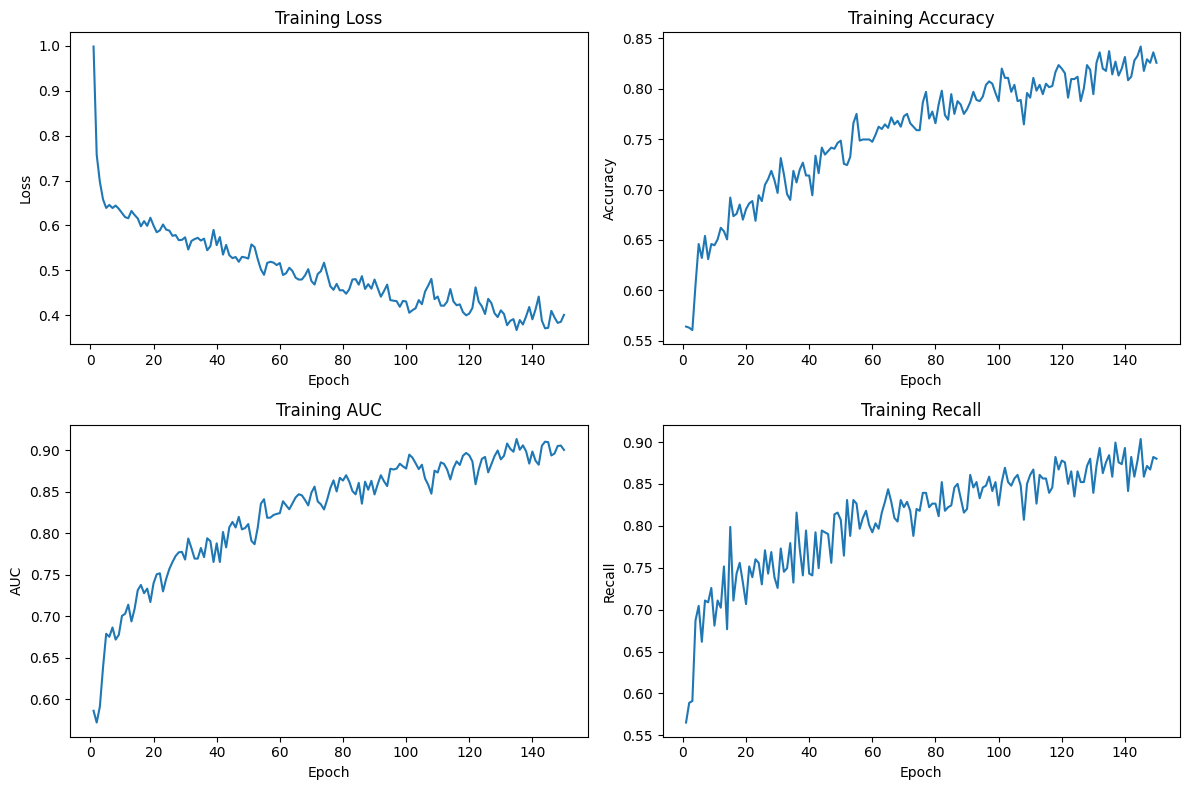

In [127]:
# plot
plot_training_history(history)

In [128]:
# predict
threshold = 0.5

y_prob_1 = model_1.predict(test_dataset)
y_pred_1 = (y_prob_1 > threshold).astype(int)
y_true_1 = test_df["label"].values

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 159ms/step


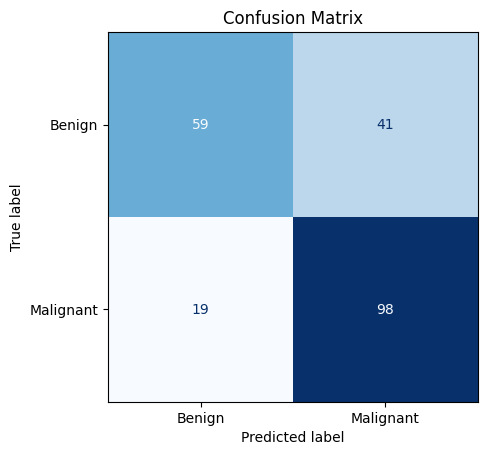

[[59 41]
 [19 98]]
              precision    recall  f1-score   support

      Benign       0.76      0.59      0.66       100
   Malignant       0.71      0.84      0.77       117

    accuracy                           0.72       217
   macro avg       0.73      0.71      0.71       217
weighted avg       0.73      0.72      0.72       217



In [129]:
plot_confusion_matrix(y_true_1, y_pred_1)

# Save Models

In [130]:
# Save the model to google drive
model_dir = Path("/content/drive/MyDrive/Grad_School/SEIS_766 Vision AI/final_project/models")
model_dir.mkdir(parents=True, exist_ok=True)

model_1_path = model_dir / f"melanoma_cnn_arch1_{EPOCHS}epochs_{BATCH_SIZE}batch_pt2.keras"
model_1.save(model_1_path)

# model_2_path = model_dir / f"melanoma_cnn_arch2_{EPOCHS}epochs_{BATCH_SIZE}batch.keras"
# model_2.save(model_2_path)

## Loading the model

Another user can load the saved model with:

```python
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/.../melanoma_cnn_arch1_35epochs.keras"
)
```

To use the model correctly, images should be preprocessed the same way they were during training:

- resize to `224 x 224`
- convert to `float32`
- scale pixel values to `[0, 1]`
- add a batch dimension before prediction

Example for predicting one image:

```python
import tensorflow as tf
import numpy as np

IMG_SIZE = (224, 224)
THRESHOLD = 0.5

def preprocess_image(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img = tf.keras.utils.img_to_array(img)
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)
    return img

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/.../melanoma_cnn_arch1_35epochs.keras"
)

image_path = "example.jpg"
image_tensor = preprocess_image(image_path)

prediction = model.predict(image_tensor, verbose=0)[0][0]
predicted_label = "Malignant" if prediction >= THRESHOLD else "Benign"

print(f"Malignant probability: {prediction:.4f}")
print(f"Predicted label: {predicted_label}")
```

Interpretation:

- output close to `1.0` means the model predicts the image is more likely malignant
- output close to `0.0` means the model predicts the image is more likely benign
- this notebook used a threshold of `0.5` for classification
